# Day 7 – Session 1: Integrating Color Detection with PyBullet Simulation


In this session, we combine the computer vision color-detection code (from earlier notebooks) with the PyBullet simulation environment. We load the same synthetic red-circle image used previously, detect the red circle using OpenCV, and compute its center in pixel coordinates. Then we map these pixel coordinates into 3D world coordinates and visualize the object in the PyBullet simulation. Mentor prompts will guide students to think about how pixel locations map to world positions and how calibration works.

Steps:
- Generate or load the synthetic red-circle image.
- Detect the red circle’s center using HSV thresholding and contour analysis.
- Map the pixel coordinates `(cx, cy)` to world coordinates `(x, y)` assuming a known scale.
- Set up a PyBullet simulation (plane + robot arm).
- Place a marker (sphere) or move the robot to the mapped position.



In [1]:
!pip install pybullet opencv-python matplotlib numpy

In [1]:
# Import required libraries
%matplotlib inline
import cv2
import numpy as np
import pybullet as p
import pybullet_data
import matplotlib.pyplot as plt

We create a synthetic 200×200 image with a red filled circle at the center.

In [ ]:
# Create a blank image and draw a red circle
'''image = np.zeros((200, 200, 3), dtype=np.uint8)
cv2.circle(image, (100, 100), 50, (0, 0, 255), -1)  # BGR red circle
print("Generated synthetic red-circle image.")'''

Generated synthetic red-circle image.


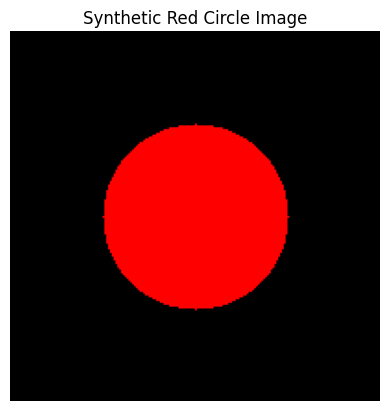

In [ ]:
# Display the synthetic image
'''plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Synthetic Red Circle Image')
plt.axis('off')
plt.show()'''

Next, convert the image to HSV color space and threshold to isolate red pixels. We use a HSV range that captures the red hue.

In [ ]:
'''hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
# Define HSV range for red color (tune these values if needed)
lower_red = np.array([0, 100, 100])
upper_red = np.array([10, 255, 255])
mask = cv2.inRange(hsv, lower_red, upper_red)
print("Applied HSV threshold for red. Nonzero mask pixels:", np.sum(mask>0))'''

Applied HSV threshold for red. Nonzero mask pixels: 7845


In [ ]:
# Find contours in the mask to locate the red object
'''contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if len(contours) > 0:
    cnt = contours[0]
    M = cv2.moments(cnt)
    if M['m00'] != 0:
        cx = int(M['m10']/M['m00'])
        cy = int(M['m01']/M['m00'])
    else:
        cx, cy = None, None
    print(f"Detected center at pixel coordinates: ({cx}, {cy})")
else:
    cx, cy = None, None
    print("No red object detected.")'''

Detected center at pixel coordinates: (100, 100)


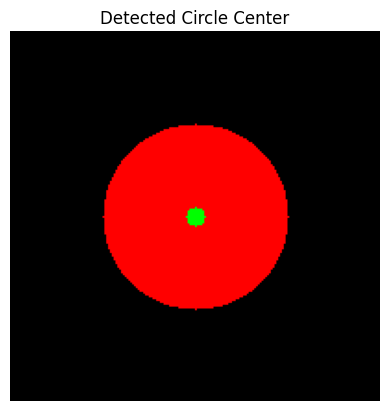

In [ ]:
# Draw the detected center on the image for visualization
'''display_image = image.copy()
if cx is not None:
    cv2.circle(display_image, (cx, cy), 5, (0, 255, 0), -1)  # green dot
plt.imshow(cv2.cvtColor(display_image, cv2.COLOR_BGR2RGB))
plt.title('Detected Circle Center')
plt.axis('off')
plt.show()'''

Now we map the pixel coordinates `(cx, cy)` to world coordinates. We assume the image covers a 1m×1m plane. Pixel `(0,0)` maps to world `(-0.5m, -0.5m)`, and pixel (width, height) maps to `(0.5m, 0.5m)`. The formula scales and offsets accordingly.

In [ ]:
'''image_height, image_width = image.shape[:2]
plane_size = 1.0  # in meters
#world_x = 0.3
#world_y = 0.2
world_x = (cx / image_width) * plane_size - plane_size/2
world_y = (cy / image_height) * plane_size - plane_size/2
print(f"Mapped to world coordinates: x = {world_x:.2f} m, y = {world_y:.2f} m (z=0 assumed)")'''

Mapped to world coordinates: x = 0.00 m, y = 0.00 m (z=0 assumed)


To verify the mapping formula, consider example corners:

In [ ]:
# Example: pixel (0,0) and (width-1, height-1) mapping
'''px, py = 0, 0
wx = (px / image_width) * plane_size - plane_size/2
wy = (py / image_height) * plane_size - plane_size/2
print(f"Pixel (0,0) → World ({wx:.2f}, {wy:.2f})")

px, py = image_width-1, image_height-1
wx = (px / image_width) * plane_size - plane_size/2
wy = (py / image_height) * plane_size - plane_size/2
print(f"Pixel ({px},{py}) → World ({wx:.2f}, {wy:.2f})")'''

Pixel (0,0) → World (-0.50, -0.50)
Pixel (199,199) → World (0.49, 0.49)


We now set up the PyBullet simulation. We load a plane and a KUKA robot arm.

<img src="https://i.postimg.cc/QNKrQSzx/Screenshot-2025-06-12-at-1-28-38-AM.png" alt="Sample Image" width="200"/>

In [1]:
# Import required libraries
%matplotlib inline
import cv2
import numpy as np
import pybullet as p
import pybullet_data
import matplotlib.pyplot as plt

In [2]:
p.connect(p.GUI)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
planeId = p.loadURDF("plane.urdf")
print("Loaded PyBullet plane.")

Loaded PyBullet plane.


In [10]:
# Load the 2-axis arm at the origin
kukaId = p.loadURDF("kuka_iiwa/model.urdf", basePosition=[0,0,0], useFixedBase=True)
num_joints = p.getNumJoints(kukaId)
print(f"Loaded KUKA with {num_joints} joints.")

Loaded KUKA with 7 joints.


We place a small red sphere at the detected world coordinates to mark the target.

In [5]:
import time
import random
import os

# --- Step 1: generate a UV-mapped sphere mesh once (so textures can wrap) ---
def make_uv_sphere_obj(filename, stacks=32, slices=32):
    verts, uvs, faces = [], [], []
    for i in range(stacks + 1):
        v = i / stacks
        theta = v * np.pi
        for j in range(slices + 1):
            u = j / slices
            phi = u * 2 * np.pi
            verts.append((np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)))
            uvs.append((u, 1 - v))
    for i in range(stacks):
        for j in range(slices):
            a = i * (slices + 1) + j + 1
            b = a + slices + 1
            faces.append((a, a + 1, b + 1, b))
    with open(filename, "w") as f:
        for x, y, z in verts: f.write(f"v {x} {y} {z}\n")
        for u, w in uvs:      f.write(f"vt {u} {w}\n")
        for a, b, c, d in faces:
            f.write(f"f {a}/{a} {b}/{b} {c}/{c} {d}/{d}\n")

SPHERE_OBJ = os.path.join(os.getcwd(), "uv_sphere.obj")
make_uv_sphere_obj(SPHERE_OBJ)


# --- Step 2: ball maker that applies texture + full physics ---
def create_sports_ball(radius, mass, lateral_friction, rolling_friction,
                       color=None, texture_path=None, position=[0, 0, 0]):
    collision_shape = p.createCollisionShape(p.GEOM_SPHERE, radius=radius)

    if texture_path:
        visual_shape = p.createVisualShape(
            shapeType=p.GEOM_MESH, fileName=SPHERE_OBJ,
            meshScale=[radius]*3, rgbaColor=[1, 1, 1, 1]
        )
    else:
        if color is None: color = [1, 1, 1, 1]
        visual_shape = p.createVisualShape(
            shapeType=p.GEOM_SPHERE, radius=radius, rgbaColor=color
        )

    ball_id = p.createMultiBody(
        baseMass=mass,
        baseCollisionShapeIndex=collision_shape,
        baseVisualShapeIndex=visual_shape, basePosition=position
    )
    p.changeDynamics(ball_id, -1,
                     lateralFriction=lateral_friction,
                     rollingFriction=rolling_friction,
                     restitution=0.75)

    if texture_path:
        tex = p.loadTexture(texture_path)
        p.changeVisualShape(ball_id, -1, textureUniqueId=tex)

    return ball_id


# --- Step 3: make the three balls ---
p.setGravity(0, 0, -9.81)

tennis_ball = create_sports_ball(
    radius=0.0327, mass=0.058,
    lateral_friction=0.6, rolling_friction=0.01,
    position=[random.uniform(-0.5, 0.5), random.uniform(-0.5, 0.5), 0.5],
    texture_path=r"c:\SB VexPushback\EZ-Template-Example-Project (1)\.vscode\Screenshot 2026-06-24 201507.jpg"
)

baseball = create_sports_ball(
    radius=0.037, mass=0.145,
    lateral_friction=0.5, rolling_friction=0.005,
    position=[random.uniform(-0.5, 0.5), random.uniform(-0.5, 0.5), 0.5],
    texture_path=r"c:\SB VexPushback\EZ-Template-Example-Project (1)\.vscode\Screenshot 2026-06-24 220302.jpg"
)

ping_pong = create_sports_ball(
    radius=0.02, mass=0.0027,
    lateral_friction=0.2, rolling_friction=0.001,
    position=[random.uniform(-0.5, 0.5), random.uniform(-0.5, 0.5), 0.5],
    color=[0.9, 0.55, 0.1, 1]
)

for _ in range(2000):
    p.stepSimulation()
    time.sleep(1./240.)

Optionally, we can use inverse kinematics to move the KUKA’s end effector near the sphere. The end-effector link index for KUKA is typically 6 (last joint).

In [ ]:
'''end_effector_index = 6
target_pos = [world_x, world_y, 0.0327 + 0.1]  # a bit above the sphere
joint_positions = p.calculateInverseKinematics(kukaId, end_effector_index, target_pos)
for j in range(num_joints):
    p.resetJointState(kukaId, j, joint_positions[j])
print("Moved KUKA end-effector near the target position.")'''


Moved KUKA end-effector near the target position.


In [7]:
import time

# Gravity on
p.setGravity(0, 0, -9.8)

tray_scale = 0.3   # change this one number to resize ALL trays at once

# Three trays at three spots, spaced out so they don't overlap
tray1 = p.loadURDF("tray/traybox.urdf", basePosition=[1,  0.0, 0], globalScaling=tray_scale)
tray2 = p.loadURDF("tray/traybox.urdf", basePosition=[1,  0.5, 0], globalScaling=tray_scale)
tray3 = p.loadURDF("tray/traybox.urdf", basePosition=[1, -0.5, 0], globalScaling=tray_scale)

print("Three trays loaded.")


Three trays loaded.


In [ ]:
# Step the simulation a few times (no visualization in DIRECT mode)
'''for _ in range(100):
    p.stepSimulation()
p.disconnect()
print("Simulation step completed and disconnected.")'''


In [ ]:
# Inspect the mask and overlays for clarity (debugging visuals):
'''print("Mask shape:", mask.shape, "Number of detected pixels:", np.sum(mask>0))
plt.imshow(mask, cmap='gray')
plt.title('Mask of Red Regions')
plt.axis('off')
plt.show()

overlay = cv2.bitwise_and(image, image, mask=mask)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title('Original Image Overlaid with Mask')
plt.axis('off')
plt.show()
'''

**🗣 Discussion & Reflection**

1. Mapping Accuracy: *If the red sphere appears offset in the PyBullet view, what could be wrong?*  
   - HSV threshold too tight or loose → centroid shifts  
   - Pixel‑to‑world scaling factor wrong (camera FOV assumption)  
   - Image center not perfectly aligned with world origin  

2. Food for Thought:
   - How would mapping change if the camera were **tilted** instead of perfectly top‑down?  
   - In a real lab, what **calibration procedure** would you use to learn the exact transform?  

3. Mini‑Exercise:
   - Move the red circle to three new pixel locations (e.g. (50,50), (150,50), (50,150)).  
   - Predict where the sphere should land in world (draw on paper), **then run** the notebook and confirm.


**Mentor Discussion Prompts**:
- How does the HSV range affect which colors are detected? What if the circle were a different shade of red?
- How do pixel distances translate to meters in the world? How was our scale of 1 meter chosen?
- Why did we place the sphere (or move the robot) at (world_x, world_y, z)? What does z represent in the simulation?
- In practice, how might you calibrate a real camera to find the exact pixel-to-world mapping?